# Customer and Segment Analysis

## Objective

This part looks at the bank's customer portfolio after cleaning the data.

Main questions:

- who the customers are
- which customer groups are most common
- which relationship segments hold stronger income and deposit value
- how loyalty tier relates to customer value
- whether credit utilization looks healthy or risky

This uses the clean customer-level dataset from the preparation step.



## 1. Import Libraries and Load Customer Data

We load `banking_customer_profiles_clean.csv`, which has one row per customer. This dataset is used for customer portfolio and segmentation analysis.


In [1]:
# Basic libraries used in this notebook
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="darkgrid", palette="deep")

# Find the project folder automatically.
cwd = Path.cwd().resolve()
project_root = cwd
while project_root != project_root.parent and not (project_root / "data" / "processed").exists():
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
tables_dir = project_root / "reports" / "tables"
figures_dir = project_root / "reports" / "figures" / "customer_segments"

for folder in [tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Processed data folder:", processed_dir)

# Load the customer-level clean dataset from EDA 1.
customer_data_path = processed_dir / "banking_customer_profiles_clean.csv"
df = pd.read_csv(customer_data_path, parse_dates=["joined_bank"])

print(f"Loaded {len(df):,} customers and {df.shape[1]} columns.")
df.head()


Project root: C:\tmp\Data_Analytics_publish_fresh\Projects\banking-customer-analytics
Processed data folder: C:\tmp\Data_Analytics_publish_fresh\Projects\banking-customer-analytics\data\processed
Loaded 15,000 customers and 30 columns.


,customer_id,customer_name,age,gender,nationality,occupation,employment_status,city,state,banking_relationship,loyalty_classification,fee_structure,investment_advisor,joined_bank,annual_income,monthly_income,bank_deposits,checking_balance,savings_balance,credit_card_limit,credit_card_balance,credit_utilization_ratio,business_lending,existing_monthly_debt_payment,total_deposit_balance,deposit_to_income_ratio,age_group,income_band,customer_tenure_years,credit_utilization_band
0,CUST00001,Vivaan Coleman,39,Male,Indian,Software Engineer,Salaried,Bengaluru,Rajasthan,Commercial,Silver,Standard,Advisor D,2012-11-27,"622,998.69","51,916.56","1,365,784.88","173,758.24","790,230.17","207,711.53","6,690.19",0.03,"743,025.13","23,011.36","2,329,773.29",3.74,36-45,Lower Middle,13.70,Low
1,CUST00002,Ayaan Sharma,46,Male,Indian,Teacher,Unknown,Chennai,Karnataka,Retail,Jade,Standard,Advisor F,2018-05-27,"656,347.95","54,695.66","1,232,480.83","58,494.62","552,113.34","46,628.12","6,594.13",0.14,"43,596.49","16,395.37","1,843,088.79",2.81,46-55,Lower Middle,8.20,Low
2,CUST00003,Aanya Khan,53,Female,Indian,Software Engineer,Self Employed,Bengaluru,Uttar Pradesh,Commercial,Jade,Standard,Advisor C,2005-05-09,"762,539.30","63,544.94","1,198,496.17","223,448.02","761,389.46","135,795.38","7,493.89",0.06,"1,074,104.35","16,676.04","2,183,333.65",2.86,46-55,Lower Middle,21.20,Low
3,CUST00004,Sai Cunningham,60,Male,Indian,Self Employed,Salaried,Delhi,Tamil Nadu,Private Bank,Gold,Premium,Advisor A,2014-12-05,"2,898,844.10","241,570.34","6,844,646.50","938,998.58","3,182,353.04","578,453.76","64,228.52",0.11,"307,539.64","24,863.10","10,965,998.12",3.78,56-65,High,11.60,Low
4,CUST00005,Meera Khan,59,Male,Middle Eastern,Teacher,Self Employed,Chennai,Rajasthan,Retail,Silver,Standard,Advisor C,2002-08-15,"1,222,523.15","101,876.93","2,390,251.60","263,331.04","1,548,728.90","154,897.45","18,215.78",0.12,"44,671.51","36,380.05","4,202,311.54",3.44,56-65,Middle,23.90,Low


### Data Used

This part uses the customer-level table. Each row represents one customer, so it is suitable for customer counts, segment mix, income, deposits, loyalty, and utilization analysis.



## 2. Basic Customer Portfolio KPIs

This section gives the first high-level view of the customer base.


In [2]:
# Create high-level customer KPIs.
customer_kpis = pd.DataFrame([
    {"metric": "Total customers", "value": len(df)},
    {"metric": "Median age", "value": round(df["age"].median(), 1)},
    {"metric": "Median annual income", "value": round(df["annual_income"].median(), 2)},
    {"metric": "Median total deposits", "value": round(df["total_deposit_balance"].median(), 2)},
    {"metric": "Average tenure years", "value": round(df["customer_tenure_years"].mean(), 1)},
])

customer_kpis


,metric,value
0,Total customers,"15,000.00"
1,Median age,47.00
2,Median annual income,"874,386.72"
3,Median total deposits,"2,344,103.97"
4,Average tenure years,14.30


### Customer Base KPIs

These KPIs give the starting point: customer count, typical age, typical income, deposit strength, and relationship length.



## 3. Age Group Analysis

Age groups help us understand whether the bank mostly serves younger, working-age, mature, or retired customers.


In [3]:
# Summarize customer count, income, deposits, and credit utilization by age group.
age_group_summary = (
    df.groupby("age_group", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_credit_utilization=("credit_utilization_ratio", "median"),
    )
    .reset_index()
)

age_group_summary["customer_pct"] = (age_group_summary["customers"] / len(df) * 100).round(2)
age_group_summary


,age_group,customers,median_income,median_deposits,median_credit_utilization,customer_pct
0,18-25,739,"861,188.69","2,316,955.23",0.22,4.93
1,26-35,2059,"888,547.69","2,371,402.37",0.21,13.73
2,36-45,4099,"882,348.89","2,397,827.46",0.21,27.33
3,46-55,4351,"874,386.72","2,306,704.63",0.22,29.01
4,56-65,2610,"865,606.38","2,296,903.75",0.22,17.40
5,66+,1142,"868,404.72","2,298,297.95",0.22,7.61


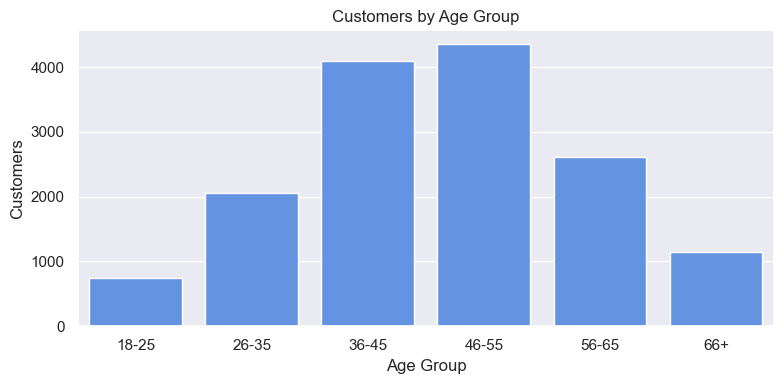

In [4]:
# Plot customer count by age group.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=age_group_summary, x="age_group", y="customers", ax=ax, color="#4f8ef7")
ax.set_title("Customers by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Customers")
fig.tight_layout()
fig.savefig(figures_dir / "customers_by_age_group.png", dpi=160, bbox_inches="tight")
plt.show()


### Age Group Result

The age-group table shows where most customers sit by life stage. This matters because deposits, borrowing needs, and financial behavior can change by age group.



## 4. Gender Distribution

Gender is checked to understand customer distribution. It is not used alone as a risk decision factor; here it is only for portfolio description.


In [5]:
# Gender-wise customer count and financial profile.
gender_summary = (
    df.groupby("gender", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_credit_utilization=("credit_utilization_ratio", "median"),
    )
    .reset_index()
)

gender_summary["customer_pct"] = (gender_summary["customers"] / len(df) * 100).round(2)
gender_summary


,gender,customers,median_income,median_deposits,median_credit_utilization,customer_pct
0,Female,6955,"874,386.72","2,360,288.10",0.22,46.37
1,Male,8045,"874,386.72","2,336,237.44",0.21,53.63


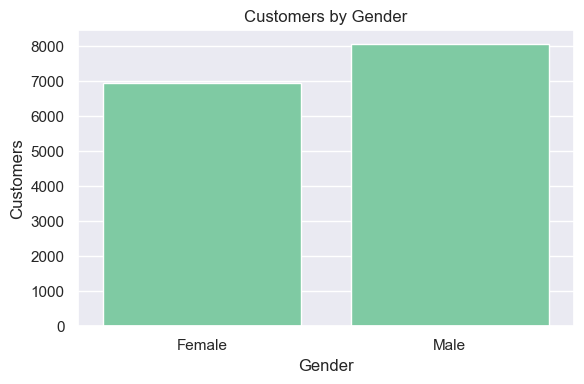

In [6]:
# Plot gender distribution.
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=gender_summary, x="gender", y="customers", ax=ax, color="#72d6a3")
ax.set_title("Customers by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Customers")
fig.tight_layout()
fig.savefig(figures_dir / "gender_percentage.png", dpi=160, bbox_inches="tight")
plt.show()


### Gender Result

This checks customer distribution by gender and compares median income and deposits. I use this only for portfolio description, not for lending decisions.



## 5. Occupation and Employment Analysis

Occupation and employment status help explain customer income patterns and banking needs.


In [7]:
# Top occupations by customer count.
occupation_summary = (
    df.groupby("occupation", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

# Employment status summary.
employment_summary = (
    df.groupby("employment_status", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

occupation_summary["customer_pct"] = (occupation_summary["customers"] / len(df) * 100).round(2)
employment_summary["customer_pct"] = (employment_summary["customers"] / len(df) * 100).round(2)

display(occupation_summary.head(10))
display(employment_summary)


,occupation,customers,median_income,median_deposits,customer_pct
0,Self Employed,879,"874,386.72","2,304,535.35",5.86
1,Retired,877,"882,612.94","2,413,327.43",5.85
2,Doctor,857,"890,030.93","2,461,199.72",5.71
3,Software Engineer,845,"881,398.42","2,348,471.71",5.63
4,Consultant,838,"887,507.10","2,309,975.30",5.59
5,Sales Manager,836,"864,546.45","2,268,156.92",5.57
6,Factory Supervisor,831,"874,386.72","2,351,409.49",5.54
7,Teacher,826,"874,386.72","2,332,605.04",5.51
8,Business Owner,823,"873,539.59","2,241,818.07",5.49
9,Shop Owner,822,"912,710.15","2,512,022.33",5.48


,employment_status,customers,median_income,median_deposits,customer_pct
0,Salaried,7102,"855,377.05","2,294,667.57",47.35
1,Self Employed,2749,"932,923.67","2,533,644.87",18.33
2,Business Owner,2661,"1,081,946.80","2,862,265.01",17.74
3,Retired,1191,"623,059.81","1,684,282.22",7.94
4,Contract,1177,"727,062.93","1,935,261.01",7.85
5,Unknown,120,"837,175.53","2,010,297.65",0.80


### Occupation and Employment Result

This shows the most common professions and employment types in the customer base. It helps explain where income and deposit patterns may be coming from.



## 6. Banking Relationship Segment Analysis

This is one of the most important sections. It compares Retail, Private Bank, Commercial, and Institutional customers.

The goal is to check whether the largest segment by count is also the most valuable by income/deposits.


In [8]:
# Relationship segment summary.
banking_relationship_summary = (
    df.groupby("banking_relationship", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_credit_utilization=("credit_utilization_ratio", "median"),
        median_tenure_years=("customer_tenure_years", "median"),
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

banking_relationship_summary["customer_pct"] = (banking_relationship_summary["customers"] / len(df) * 100).round(2)
banking_relationship_summary


,banking_relationship,customers,median_income,median_deposits,median_credit_utilization,median_tenure_years,customer_pct
0,Retail,7821,"753,706.67","2,012,534.87",0.22,14.30,52.14
1,Private Bank,3496,"1,108,769.58","2,957,191.09",0.21,14.30,23.31
2,Commercial,2082,"995,834.66","2,691,762.33",0.21,14.00,13.88
3,Institutional,1601,"908,400.33","2,479,798.47",0.22,14.10,10.67


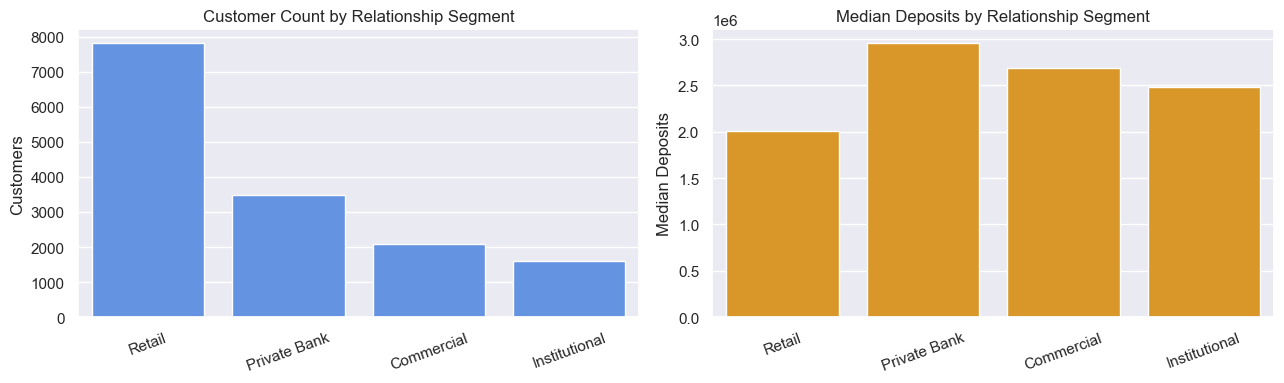

In [9]:
# Plot segment size and median deposits side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=banking_relationship_summary, x="banking_relationship", y="customers", ax=axes[0], color="#4f8ef7")
axes[0].set_title("Customer Count by Relationship Segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customers")

sns.barplot(data=banking_relationship_summary, x="banking_relationship", y="median_deposits", ax=axes[1], color="#f59e0b")
axes[1].set_title("Median Deposits by Relationship Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median Deposits")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(figures_dir / "banking_relationship_percentage.png", dpi=160, bbox_inches="tight")
plt.show()


### Relationship Segment Result

This separates customer volume from customer value. The largest segment by count is not always the strongest segment by deposits or income.



## 7. Loyalty Tier Analysis

Loyalty tier is checked to see whether long-term or premium customers hold stronger deposit value.


In [10]:
# Loyalty tier summary.
loyalty_summary = (
    df.groupby("loyalty_classification", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_tenure_years=("customer_tenure_years", "median"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .sort_values("median_deposits", ascending=False)
    .reset_index()
)

loyalty_summary["customer_pct"] = (loyalty_summary["customers"] / len(df) * 100).round(2)
loyalty_summary


,loyalty_classification,customers,median_tenure_years,median_income,median_deposits,customer_pct
0,Platinum,1954,14.80,"1,172,548.90","4,902,203.87",13.03
1,Gold,3716,14.10,"952,596.50","2,989,521.35",24.77
2,Silver,4540,14.00,"828,441.49","2,148,981.08",30.27
3,Jade,4790,14.30,"773,544.98","1,673,124.54",31.93


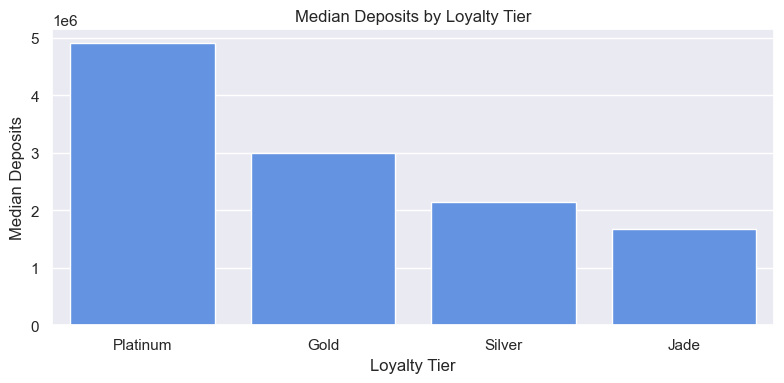

In [11]:
# Plot median deposits by loyalty tier.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=loyalty_summary, x="loyalty_classification", y="median_deposits", ax=ax, color="#4f8ef7")
ax.set_title("Median Deposits by Loyalty Tier")
ax.set_xlabel("Loyalty Tier")
ax.set_ylabel("Median Deposits")
fig.tight_layout()
fig.savefig(figures_dir / "loyalty_deposit_value.png", dpi=160, bbox_inches="tight")
plt.show()


### Loyalty Result

This checks whether higher loyalty tiers are linked with stronger deposit balances. If the pattern is clear, loyalty tier can help with retention and relationship planning.



## 8. Income Band and Relationship Mix

This section connects customer value with relationship type. It shows how income bands are distributed across Retail, Private Bank, Commercial, and Institutional segments.


In [12]:
# Income band summary.
income_band_summary = (
    df.groupby("income_band", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_credit_utilization=("credit_utilization_ratio", "median"),
    )
    .reset_index()
)

income_band_summary["customer_pct"] = (income_band_summary["customers"] / len(df) * 100).round(2)

# Relationship by income band table.
relationship_income_summary = (
    df.groupby(["banking_relationship", "income_band"], observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .reset_index()
)

display(income_band_summary)
display(relationship_income_summary.head(15))


,income_band,customers,median_income,median_deposits,median_credit_utilization,customer_pct
0,Affluent,144,"3,494,126.65","11,598,840.61",0.24,0.96
1,High,2160,"1,831,517.25","5,648,448.29",0.21,14.40
2,Low,958,"334,465.34","810,125.35",0.23,6.39
3,Lower Middle,5441,"609,520.61","1,579,848.13",0.22,36.27
4,Middle,6297,"1,047,938.51","2,929,163.00",0.21,41.98


,banking_relationship,income_band,customers,median_income,median_deposits
0,Commercial,Affluent,22,"3,802,323.34","11,744,227.80"
1,Commercial,High,392,"1,853,676.69","5,710,382.04"
2,Commercial,Low,60,"339,971.69","883,384.67"
3,Commercial,Lower Middle,617,"631,612.31","1,580,363.67"
4,Commercial,Middle,991,"1,074,459.62","2,939,343.44"
5,Institutional,Affluent,14,"3,268,016.96","11,733,297.07"
6,Institutional,High,258,"1,817,330.30","5,595,091.33"
7,Institutional,Low,80,"359,634.18","866,406.49"
8,Institutional,Lower Middle,527,"630,832.49","1,599,176.92"
9,Institutional,Middle,722,"1,055,398.94","2,928,573.52"


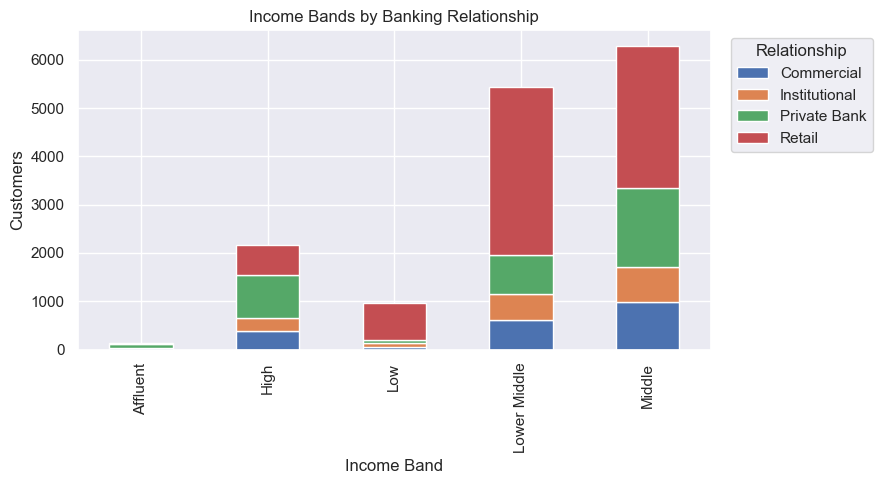

In [13]:
# Stacked chart: income bands by relationship segment.
income_relationship_pivot = (
    df.groupby(["income_band", "banking_relationship"], observed=False)
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 5))
income_relationship_pivot.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Income Bands by Banking Relationship")
ax.set_xlabel("Income Band")
ax.set_ylabel("Customers")
ax.legend(title="Relationship", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(figures_dir / "loyalty_vs_banking_relationship.png", dpi=160, bbox_inches="tight")
plt.show()


### Income Band Result

Income-band analysis shows where customer value sits inside the portfolio and how income groups are distributed across relationship segments.



## 9. Credit Utilization Analysis

Credit utilization shows how much of the available credit card limit customers are using. It is useful because very high utilization can indicate financial stress.


In [14]:
# Credit utilization summary.
credit_utilization_summary = (
    df.groupby("credit_utilization_band", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_card_balance=("credit_card_balance", "median"),
        median_credit_limit=("credit_card_limit", "median"),
    )
    .reset_index()
)

credit_utilization_summary["customer_pct"] = (credit_utilization_summary["customers"] / len(df) * 100).round(2)
credit_utilization_summary


,credit_utilization_band,customers,median_income,median_card_balance,median_credit_limit,customer_pct
0,High,369,"874,386.72","120,784.22","187,622.72",2.46
1,Low,10257,"874,386.72","24,323.80","179,701.59",68.38
2,Maxed,6,"988,007.47","169,159.26","190,332.38",0.04
3,Moderate,4368,"874,386.72","72,064.49","180,890.77",29.12


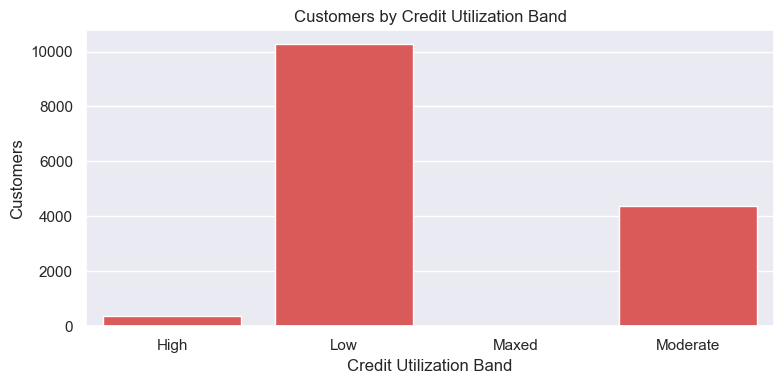

In [15]:
# Plot credit utilization bands.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=credit_utilization_summary, x="credit_utilization_band", y="customers", ax=ax, color="#ef4444")
ax.set_title("Customers by Credit Utilization Band")
ax.set_xlabel("Credit Utilization Band")
ax.set_ylabel("Customers")
fig.tight_layout()
fig.savefig(figures_dir / "credit_utilization_bands.png", dpi=160, bbox_inches="tight")
plt.show()


### Credit Utilization Result

This checks whether customers are using credit conservatively or aggressively. High utilization can become a useful risk signal later.



## 10. Advisor Portfolio Analysis

Advisor analysis shows how customers and deposit value are distributed across relationship managers/advisors.


In [16]:
# Advisor-wise customer and deposit summary.
advisor_summary = (
    df.groupby("investment_advisor", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        total_deposits=("total_deposit_balance", "sum"),
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

advisor_summary.head(10)


,investment_advisor,customers,median_income,median_deposits,total_deposits
0,Advisor D,2557,"874,386.72","2,379,802.77","7,755,718,304.01"
1,Advisor A,2546,"874,386.72","2,413,574.58","7,698,696,394.84"
2,Advisor B,2499,"875,203.48","2,368,530.62","7,561,186,323.21"
3,Advisor E,2482,"858,261.47","2,248,827.36","7,355,388,799.79"
4,Advisor C,2465,"874,386.72","2,324,017.19","7,486,156,802.23"
5,Advisor F,2451,"874,386.72","2,332,425.30","7,425,488,021.46"


### Advisor Result

Advisor-level analysis shows portfolio size and value concentration by relationship manager. This can help understand workload and service focus.



## 11. Deeper Customer Portfolio Visual Analysis

The earlier sections show grouped tables. Here I add stronger visual checks so the customer portfolio is easier to understand.

This section uses:

- histograms for distribution shape
- boxplots for value spread and outliers
- scatter plots for relationships between income, deposits, and credit utilization
- donut charts for segment share
- heatmaps for cross-segment patterns


### 11.1 Distribution Checks

I first check the spread of age, income, deposits, and credit utilization. These distributions show whether the customer base is balanced or skewed.


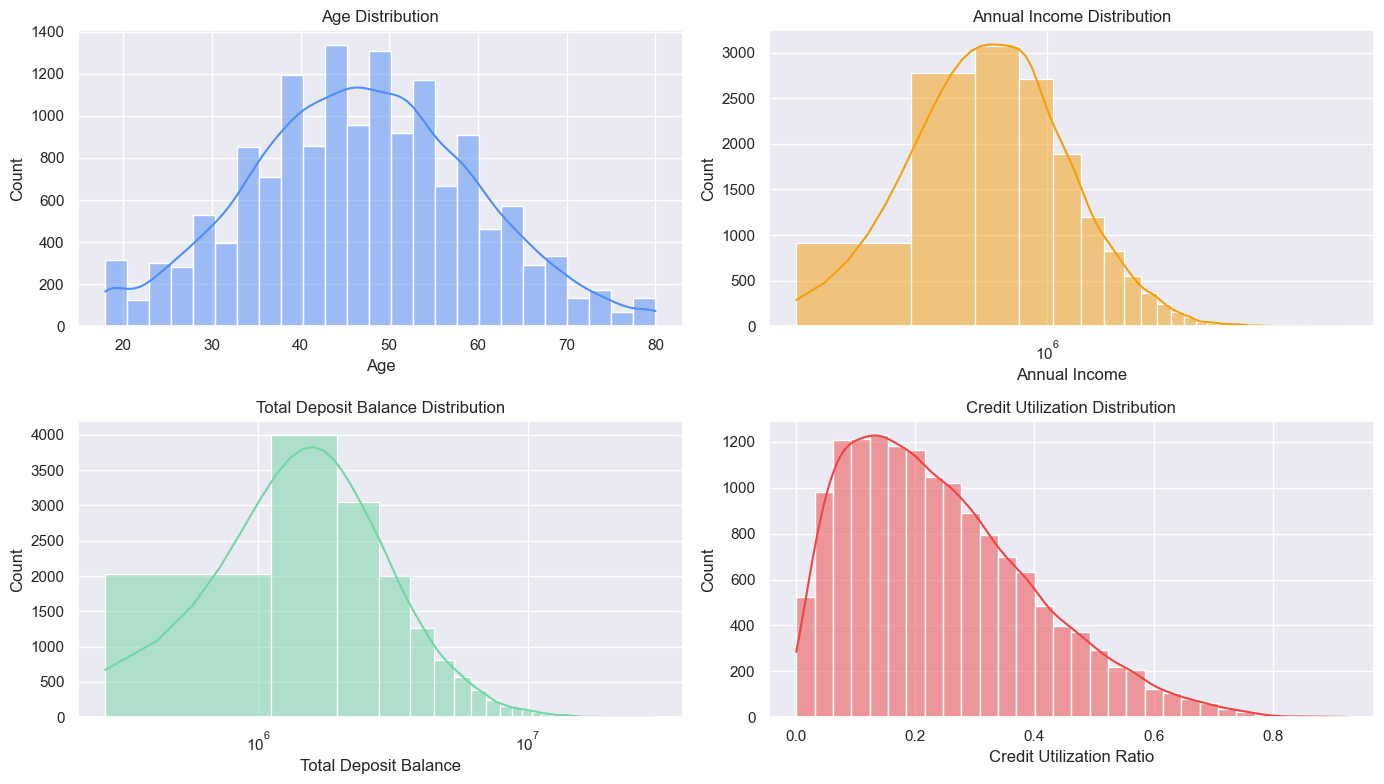

In [17]:
# Distribution plots for important customer fields.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

sns.histplot(df["age"], bins=25, kde=True, ax=axes[0], color="#4f8ef7")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

sns.histplot(df["annual_income"], bins=35, kde=True, ax=axes[1], color="#f59e0b")
axes[1].set_title("Annual Income Distribution")
axes[1].set_xlabel("Annual Income")
axes[1].set_xscale("log")

sns.histplot(df["total_deposit_balance"], bins=35, kde=True, ax=axes[2], color="#72d6a3")
axes[2].set_title("Total Deposit Balance Distribution")
axes[2].set_xlabel("Total Deposit Balance")
axes[2].set_xscale("log")

sns.histplot(df["credit_utilization_ratio"], bins=30, kde=True, ax=axes[3], color="#ef4444")
axes[3].set_title("Credit Utilization Distribution")
axes[3].set_xlabel("Credit Utilization Ratio")

fig.tight_layout()
fig.savefig(figures_dir / "customer_distribution_checks.png", dpi=160, bbox_inches="tight")
plt.show()



### Distribution Result

Income and deposits are right-skewed. That is expected in banking because a smaller group of customers usually holds much higher balances than the median customer.



### 11.2 Boxplots by Segment

Boxplots show value spread, not just average or median. This is useful because customer value is usually uneven inside each relationship segment.


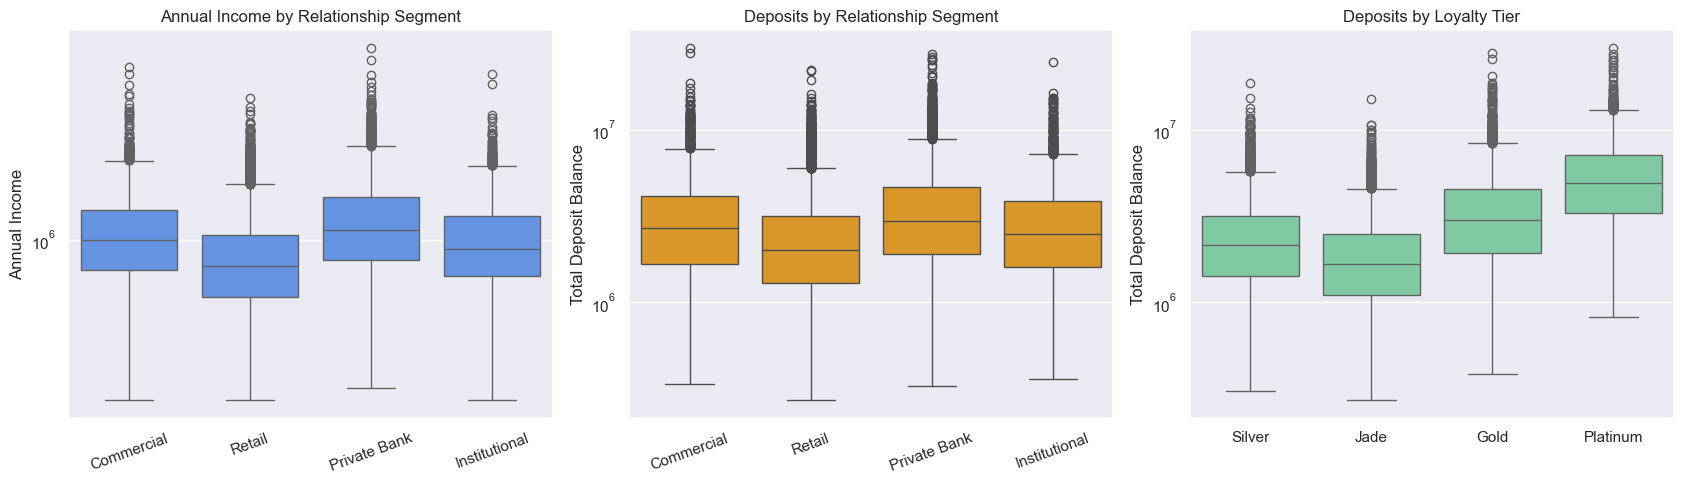

In [18]:
# Boxplots for income and deposits by customer segment.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(data=df, x="banking_relationship", y="annual_income", ax=axes[0], color="#4f8ef7")
axes[0].set_title("Annual Income by Relationship Segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Annual Income")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="banking_relationship", y="total_deposit_balance", ax=axes[1], color="#f59e0b")
axes[1].set_title("Deposits by Relationship Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Deposit Balance")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="loyalty_classification", y="total_deposit_balance", ax=axes[2], color="#72d6a3")
axes[2].set_title("Deposits by Loyalty Tier")
axes[2].set_xlabel("")
axes[2].set_ylabel("Total Deposit Balance")
axes[2].set_yscale("log")

fig.tight_layout()
fig.savefig(figures_dir / "customer_value_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()



### Boxplot Result

The boxplots show customer value is different across segments. Private Bank and Commercial customers generally have stronger income and deposit levels than Retail customers. Platinum loyalty customers show the strongest deposit value.



### 11.3 Scatter Plot Relationships

Scatter plots help check whether two numeric fields move together. Here I compare income, deposits, and credit utilization.


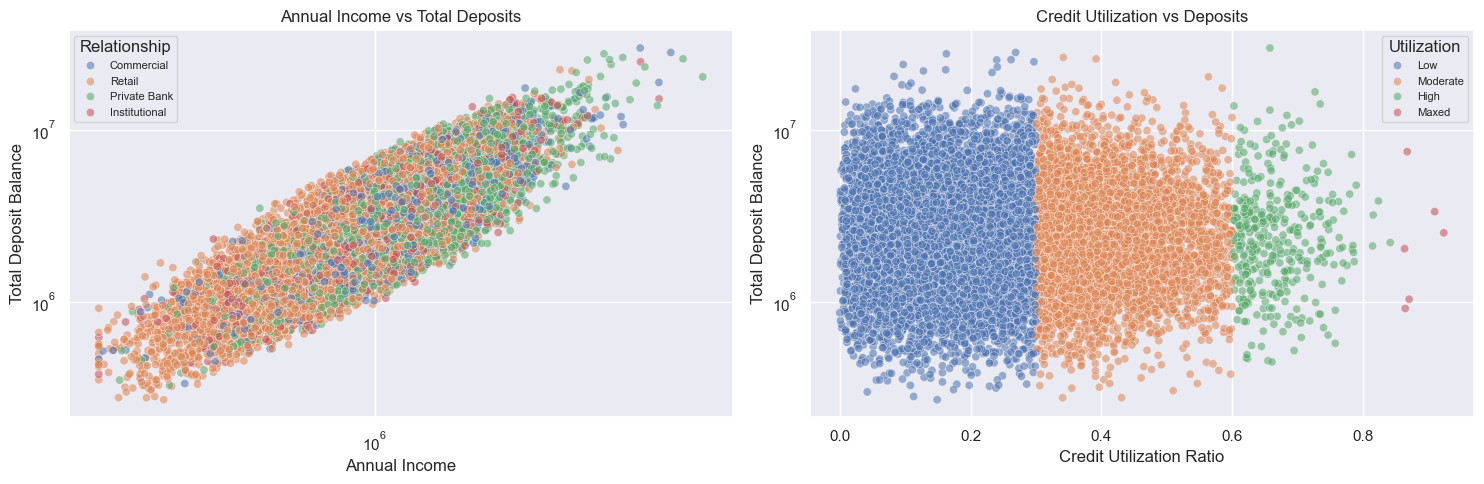

In [19]:
# Scatter plots for important customer relationships.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="total_deposit_balance",
    hue="banking_relationship",
    alpha=0.55,
    ax=axes[0],
)
axes[0].set_title("Annual Income vs Total Deposits")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Total Deposit Balance")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].legend(title="Relationship", fontsize=8)

sns.scatterplot(
    data=df,
    x="credit_utilization_ratio",
    y="total_deposit_balance",
    hue="credit_utilization_band",
    alpha=0.55,
    ax=axes[1],
)
axes[1].set_title("Credit Utilization vs Deposits")
axes[1].set_xlabel("Credit Utilization Ratio")
axes[1].set_ylabel("Total Deposit Balance")
axes[1].set_yscale("log")
axes[1].legend(title="Utilization", fontsize=8)

fig.tight_layout()
fig.savefig(figures_dir / "customer_scatter_relationships.png", dpi=160, bbox_inches="tight")
plt.show()



### Scatter Plot Result

Income and deposits generally rise together, but there is still spread inside every segment. Credit utilization is mostly low or moderate for most customers.



### 11.4 Donut Charts for Portfolio Share

Donut charts are useful here because they show the share of each segment in the customer base.


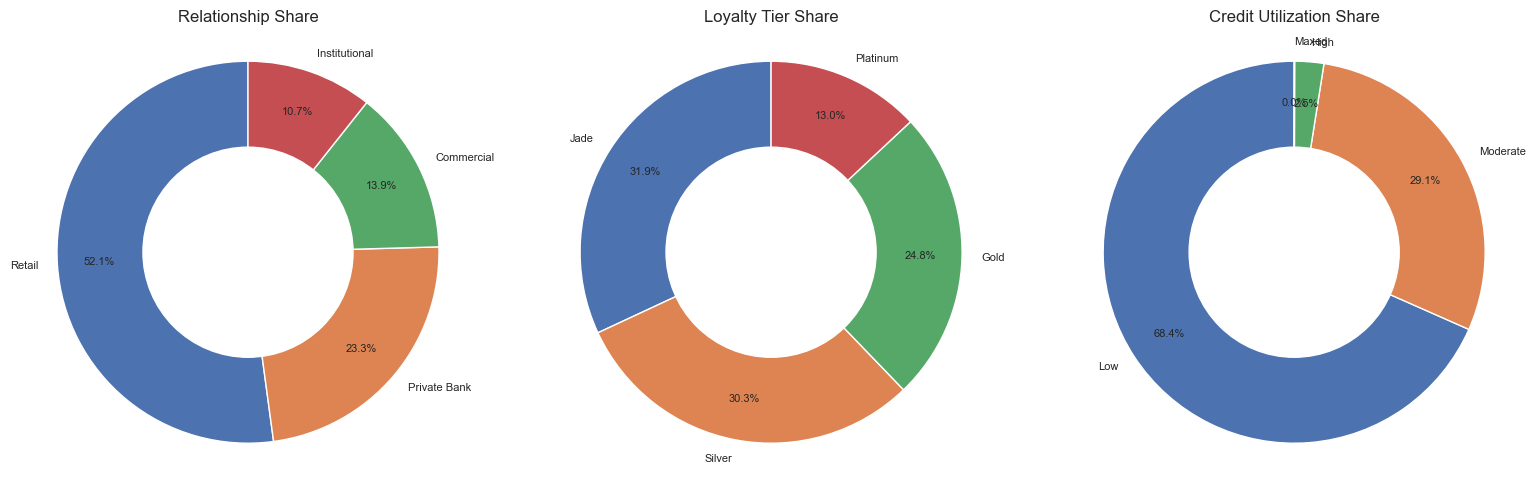

In [20]:
# Donut chart helper.
def plot_donut(ax, labels, values, title):
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.78,
        textprops={"fontsize": 8},
    )
    centre_circle = plt.Circle((0, 0), 0.55, fc="white")
    ax.add_artist(centre_circle)
    ax.set_title(title)
    ax.axis("equal")

relationship_counts = df["banking_relationship"].value_counts()
loyalty_counts = df["loyalty_classification"].value_counts()
utilization_counts = df["credit_utilization_band"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_donut(axes[0], relationship_counts.index, relationship_counts.values, "Relationship Share")
plot_donut(axes[1], loyalty_counts.index, loyalty_counts.values, "Loyalty Tier Share")
plot_donut(axes[2], utilization_counts.index, utilization_counts.values, "Credit Utilization Share")
fig.tight_layout()
fig.savefig(figures_dir / "customer_segment_donut_charts.png", dpi=160, bbox_inches="tight")
plt.show()



### Portfolio Mix Result

The donut charts make the portfolio mix easy to read. Retail is the largest relationship segment, Jade and Silver are the largest loyalty groups, and most customers fall into low or moderate credit utilization.



### 11.5 Heatmaps for Cross-Segment Patterns

Heatmaps show how two categories interact. I use them to compare relationship segment with loyalty tier and income band.


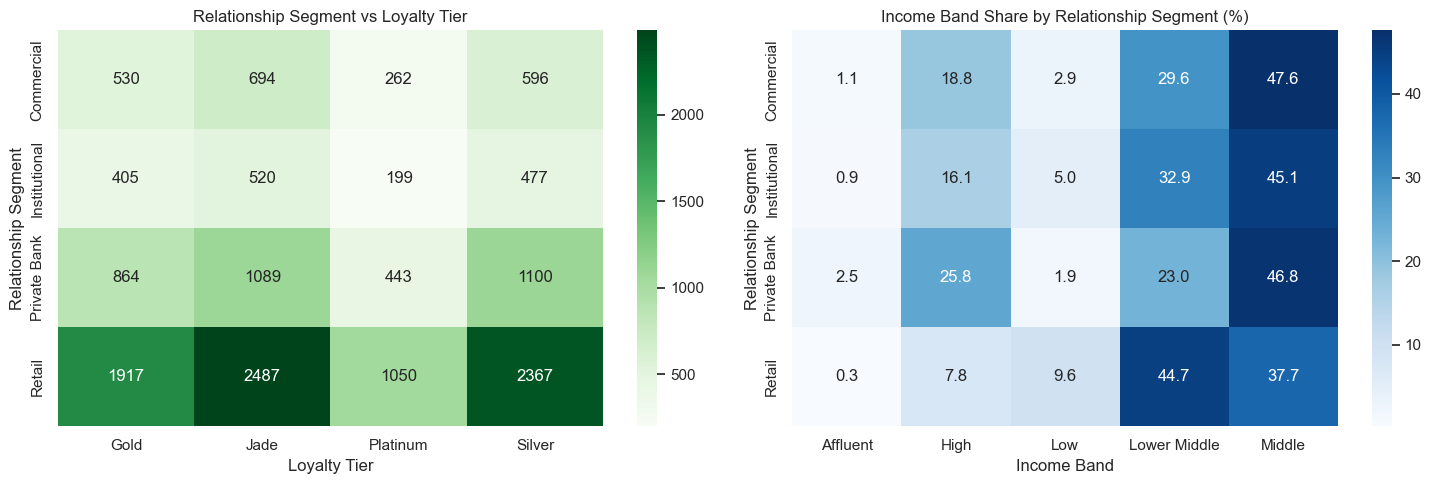

loyalty_classification,Gold,Jade,Platinum,Silver
banking_relationship,,,,
Commercial,530,694,262,596
Institutional,405,520,199,477
Private Bank,864,1089,443,1100
Retail,1917,2487,1050,2367


income_band,Affluent,High,Low,Lower Middle,Middle
banking_relationship,,,,,
Commercial,1.06,18.83,2.88,29.63,47.60
Institutional,0.87,16.11,5.00,32.92,45.10
Private Bank,2.52,25.77,1.89,23.00,46.82
Retail,0.26,7.79,9.62,44.66,37.68


In [21]:
# Relationship vs loyalty count heatmap.
relationship_loyalty_matrix = pd.crosstab(
    df["banking_relationship"],
    df["loyalty_classification"],
)

# Relationship vs income band percentage heatmap.
relationship_income_pct = pd.crosstab(
    df["banking_relationship"],
    df["income_band"],
    normalize="index",
).mul(100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(relationship_loyalty_matrix, annot=True, fmt="d", cmap="Greens", ax=axes[0])
axes[0].set_title("Relationship Segment vs Loyalty Tier")
axes[0].set_xlabel("Loyalty Tier")
axes[0].set_ylabel("Relationship Segment")

sns.heatmap(relationship_income_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("Income Band Share by Relationship Segment (%)")
axes[1].set_xlabel("Income Band")
axes[1].set_ylabel("Relationship Segment")

fig.tight_layout()
fig.savefig(figures_dir / "customer_segment_heatmaps.png", dpi=160, bbox_inches="tight")
plt.show()

display(relationship_loyalty_matrix)
display(relationship_income_pct)



### Segment Mix Result

The heatmaps show how loyalty and income groups are distributed inside each relationship segment. This gives a better view than only looking at total customer counts.



### 11.6 Occupation Value Check

Customer count alone is not enough. This chart checks which occupations have higher median deposits among common occupations.


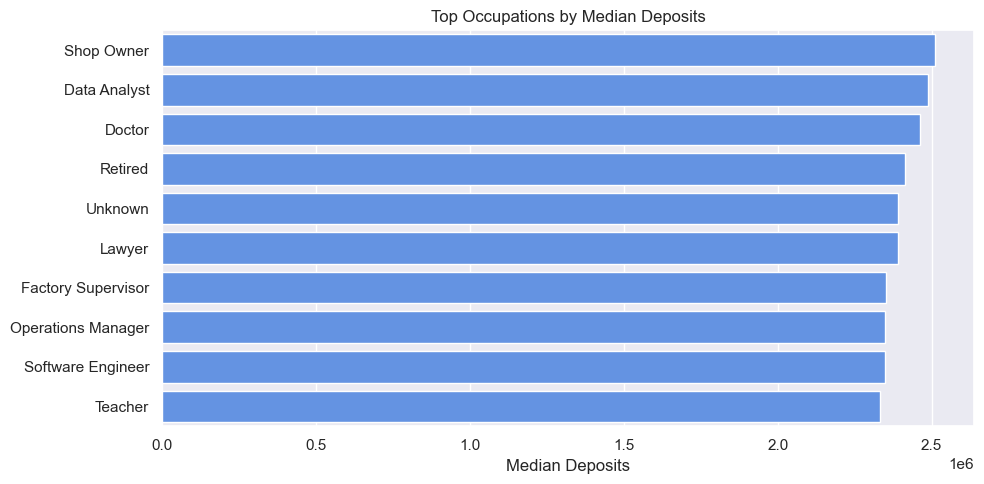

,occupation,customers,median_income,median_deposits
0,Shop Owner,822,"912,710.15","2,512,022.33"
1,Data Analyst,792,"891,442.28","2,488,368.04"
2,Doctor,857,"890,030.93","2,461,199.72"
3,Retired,877,"882,612.94","2,413,327.43"
4,Unknown,150,"847,260.89","2,391,857.48"
5,Lawyer,813,"866,652.62","2,389,137.13"
6,Factory Supervisor,831,"874,386.72","2,351,409.49"
7,Operations Manager,822,"874,386.72","2,349,642.70"
8,Software Engineer,845,"881,398.42","2,348,471.71"
9,Teacher,826,"874,386.72","2,332,605.04"


In [22]:
# Top occupations by median deposits, only where enough customers exist.
occupation_value_summary = (
    df.groupby("occupation", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .query("customers >= 50")
    .sort_values("median_deposits", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=occupation_value_summary.head(10), y="occupation", x="median_deposits", ax=ax, color="#4f8ef7")
ax.set_title("Top Occupations by Median Deposits")
ax.set_xlabel("Median Deposits")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(figures_dir / "top_occupations_by_deposit_value.png", dpi=160, bbox_inches="tight")
plt.show()

occupation_value_summary.head(10)



### Occupation Value Result

This compares occupations by deposit value, not only by count. It helps separate common occupations from financially stronger customer groups.



## 12. Final Customer Segment Insights

This section keeps the main customer-segment findings in one place.



In [23]:
# Pull key values from the summary tables.
largest_age_group = age_group_summary.sort_values("customers", ascending=False).iloc[0]
largest_relationship = banking_relationship_summary.sort_values("customers", ascending=False).iloc[0]
highest_deposit_relationship = banking_relationship_summary.sort_values("median_deposits", ascending=False).iloc[0]
highest_deposit_loyalty = loyalty_summary.sort_values("median_deposits", ascending=False).iloc[0]
largest_utilization_band = credit_utilization_summary.sort_values("customers", ascending=False).iloc[0]
highest_value_occupation = occupation_value_summary.sort_values("median_deposits", ascending=False).iloc[0]

customer_segment_insights = pd.DataFrame([
    {
        "finding": "Largest age group",
        "result": f"{largest_age_group['age_group']} with {int(largest_age_group['customers']):,} customers"
    },
    {
        "finding": "Largest relationship segment",
        "result": f"{largest_relationship['banking_relationship']} with {int(largest_relationship['customers']):,} customers ({largest_relationship['customer_pct']:.2f}%)"
    },
    {
        "finding": "Highest median deposit relationship",
        "result": f"{highest_deposit_relationship['banking_relationship']} with median deposits INR {highest_deposit_relationship['median_deposits']:,.0f}"
    },
    {
        "finding": "Highest deposit loyalty tier",
        "result": f"{highest_deposit_loyalty['loyalty_classification']} with median deposits INR {highest_deposit_loyalty['median_deposits']:,.0f}"
    },
    {
        "finding": "Most common credit utilization band",
        "result": f"{largest_utilization_band['credit_utilization_band']} with {int(largest_utilization_band['customers']):,} customers"
    },
    {
        "finding": "Highest value common occupation",
        "result": f"{highest_value_occupation['occupation']} with median deposits INR {highest_value_occupation['median_deposits']:,.0f}"
    },
])

customer_segment_insights


,finding,result
0,Largest age group,"46-55 with 4,351 customers"
1,Largest relationship segment,"Retail with 7,821 customers (52.14%)"
2,Highest median deposit relationship,"Private Bank with median deposits INR 2,957,191"
3,Highest deposit loyalty tier,"Platinum with median deposits INR 4,902,204"
4,Most common credit utilization band,"Low with 10,257 customers"
5,Highest value common occupation,"Shop Owner with median deposits INR 2,512,022"


### Insight Table Result

The final table summarizes the main customer findings: largest segment, strongest value segment, strongest loyalty tier, and overall credit-utilization pattern.



## 13. Export Tables

All tables are exported so they can be reused in the README, report, dashboard, or presentation.


In [24]:
customer_kpis.to_csv(tables_dir / "customer_kpis.csv", index=False)
age_group_summary.to_csv(tables_dir / "age_group_summary.csv", index=False)
gender_summary.to_csv(tables_dir / "gender_summary.csv", index=False)
occupation_summary.to_csv(tables_dir / "occupation_summary.csv", index=False)
employment_summary.to_csv(tables_dir / "employment_summary.csv", index=False)
banking_relationship_summary.to_csv(tables_dir / "banking_relationship_summary.csv", index=False)
loyalty_summary.to_csv(tables_dir / "loyalty_summary.csv", index=False)
income_band_summary.to_csv(tables_dir / "income_band_summary.csv", index=False)
relationship_income_summary.to_csv(tables_dir / "relationship_income_summary.csv", index=False)
credit_utilization_summary.to_csv(tables_dir / "credit_utilization_summary.csv", index=False)
advisor_summary.to_csv(tables_dir / "advisor_summary.csv", index=False)
customer_segment_insights.to_csv(tables_dir / "customer_segment_insights.csv", index=False)
relationship_loyalty_matrix.to_csv(tables_dir / "relationship_loyalty_matrix.csv")
relationship_income_pct.to_csv(tables_dir / "relationship_income_pct.csv")
occupation_value_summary.to_csv(tables_dir / "occupation_value_summary.csv", index=False)

exported_tables = pd.DataFrame([
    {"table": "customer_kpis.csv", "purpose": "overall customer portfolio KPIs"},
    {"table": "banking_relationship_summary.csv", "purpose": "relationship segment comparison"},
    {"table": "loyalty_summary.csv", "purpose": "loyalty tier value comparison"},
    {"table": "credit_utilization_summary.csv", "purpose": "credit utilization behavior"},
    {"table": "customer_segment_insights.csv", "purpose": "final interview-ready insights"},
])
exported_tables


,table,purpose
0,customer_kpis.csv,overall customer portfolio KPIs
1,banking_relationship_summary.csv,relationship segment comparison
2,loyalty_summary.csv,loyalty tier value comparison
3,credit_utilization_summary.csv,credit utilization behavior
4,customer_segment_insights.csv,final interview-ready insights


### Saved Outputs

The customer-segment tables and charts were saved successfully. These outputs explain the customer portfolio before moving into lending-risk analysis.



## 14. Final Summary

I analyzed the cleaned customer-level data to understand the bank's customer base, segment mix, deposit value, loyalty pattern, and credit utilization.

### Customer Base

The dataset has 15,000 customers.

Basic profile:

- median age: 47
- median annual income: INR 874,387
- median total deposits: INR 2,344,104
- average customer tenure: 14.3 years

### Age Groups

The largest age group is `46-55` with 4,351 customers. The next largest group is `36-45` with 4,099 customers.

This means a large part of the bank's customer base is middle-aged, which is useful for deposits, lending, and long-term relationship products.

### Relationship Segments

Customer count by relationship segment:

- Retail: 7,821 customers, 52.14%
- Private Bank: 3,496 customers, 23.31%
- Commercial: 2,082 customers, 13.88%
- Institutional: 1,601 customers, 10.67%

Retail is the largest segment by count, but it is not the highest-value segment.

Median deposits by relationship:

- Retail: INR 2,012,535
- Private Bank: INR 2,957,191
- Commercial: INR 2,691,762
- Institutional: INR 2,479,798

Private Bank and Commercial customers hold stronger deposit value than Retail customers.

### Loyalty Tiers

Median deposits by loyalty tier:

- Platinum: INR 4,902,204
- Gold: INR 2,989,521
- Silver: INR 2,148,981
- Jade: INR 1,673,125

Deposit value increases clearly with loyalty tier. Platinum customers have the highest median deposits.

### Credit Utilization

Credit utilization bands:

- Low: 10,257 customers, 68.38%
- Moderate: 4,368 customers, 29.12%
- High: 369 customers, 2.46%
- Maxed: 6 customers, 0.04%

Most customers are in low or moderate utilization bands, so the overall customer base does not look heavily dependent on credit card borrowing.

### Visual Findings

The histograms and boxplots show income and deposits are right-skewed. This is normal for banking data because a smaller group of customers holds much higher balances.

The income vs deposit scatter plot shows that higher-income customers generally hold higher deposits, but there is still variation inside each segment.

The heatmaps show the mix of loyalty and income bands inside each relationship segment, which helps compare segment quality instead of only segment size.

### What This Shows

The bank has a large Retail base, but stronger customer value is more visible in Private Bank, Commercial, and higher loyalty tiers. This separates customer count from customer value and helps with retention, cross-selling, and lending-risk decisions.
